In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import gropt
from helper_utils import *
import gropt
from gropt_diffusion2 import *
from trap_diffusion3 import *

In [2]:
# -------------------------------
# Settings
# -------------------------------
bvals = [1000, 3000]
gm = 0.19
mmts = [0, 1]  
scenario = "PNS-Limited"

In [3]:
import numpy as np

# -------------------------------
# Container for loaded data
# -------------------------------
data_dict = {}

# -------------------------------
# Load all files
# -------------------------------
for b in bvals:
    for mmt in mmts:
        # Construct file name
        file_name = f"pulseq_diffusion_waveform_params_{scenario}_b{b}_g{gm:.2f}_m{mmt}.npz"
        
        # Load .npz
        data = np.load(file_name, allow_pickle=True)
        #print each key
        print(f"Loaded data from {file_name}:")
       # Store relevant waveforms and timing in a nested dictionary
        data_dict[(b, mmt)] = {
            'g_gropt': data['last_good_result'],
            'dt_gropt': data['dt_gropt'].item(),
            't_gropt': data['t_array'],
            'g_trap': data['g_waveform_trap'],
            'dt_trap': data['dt_trap'].item(),
            't_trap': data['timings_trap'],
            'TE_trap': data['TE_trap'].item(),
            'TE_gropt': data['last_good_TE'].item()
        }


# -------------------------------
# Example access
# -------------------------------
# For b=1000, mmt=0
g_gropt_b1000_m0 = data_dict[(1000, 0)]['g_gropt']
t_gropt_b1000_m0 = data_dict[(1000, 0)]['t_gropt']


Loaded data from pulseq_diffusion_waveform_params_PNS-Limited_b1000_g0.19_m0.npz:
Loaded data from pulseq_diffusion_waveform_params_PNS-Limited_b1000_g0.19_m1.npz:
Loaded data from pulseq_diffusion_waveform_params_PNS-Limited_b3000_g0.19_m0.npz:
Loaded data from pulseq_diffusion_waveform_params_PNS-Limited_b3000_g0.19_m1.npz:


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Helper functions
# ============================================================
def compute_q(G, dt, gamma=267.522190e6, TE = None):
    """
    Compute q-vector from gradient waveform G (T/m)
    gamma in rad/s/T (default proton)
    """
    G = np.asarray(G)
    if G.ndim == 1:
        G = G[:, None]  # convert to 2D for consistency
    
    if TE is not None:
        # from TE/2 to end of G * -1
        mid_idx = int(TE / (2 * dt))
        G[mid_idx:, :] *= -1
    
    #plt.plot(np.arange(G.shape[0]) * dt, G  )
    #plt.show()

    gamma = gamma / 1000.0  # rad/s/mm
    G_int = np.cumsum(G, axis=0) * dt
    q = gamma * G_int  # rad/mm
    return q.squeeze()  # return 1D if single axis

def q_to_energy(q, dt):
    """
    Compute FULL symmetric power spectrum of q-vector
    Returns:
        f_shift : frequencies (Hz), negative -> positive
        omega_shift : angular frequencies (rad/s)
        energy : |Q(omega)|^2 properly normalized
    """
    q = np.asarray(q)
    N = len(q)

    # Full FFT
    Q = np.fft.fft(q)
    # Normalize by N to get correct amplitude
    Q = Q / N

    # Shift for symmetric spectrum
    Q_shift = np.fft.fftshift(Q)
    f_shift = np.fft.fftshift(np.fft.fftfreq(N, dt))
    omega_shift = 2 * np.pi * f_shift

    energy = np.abs(Q_shift)**2
    return f_shift, omega_shift, energy

Difference -3.905710449218752
Difference -17.388018188476558
Difference -4.245438232421877
Difference -17.14817749023438


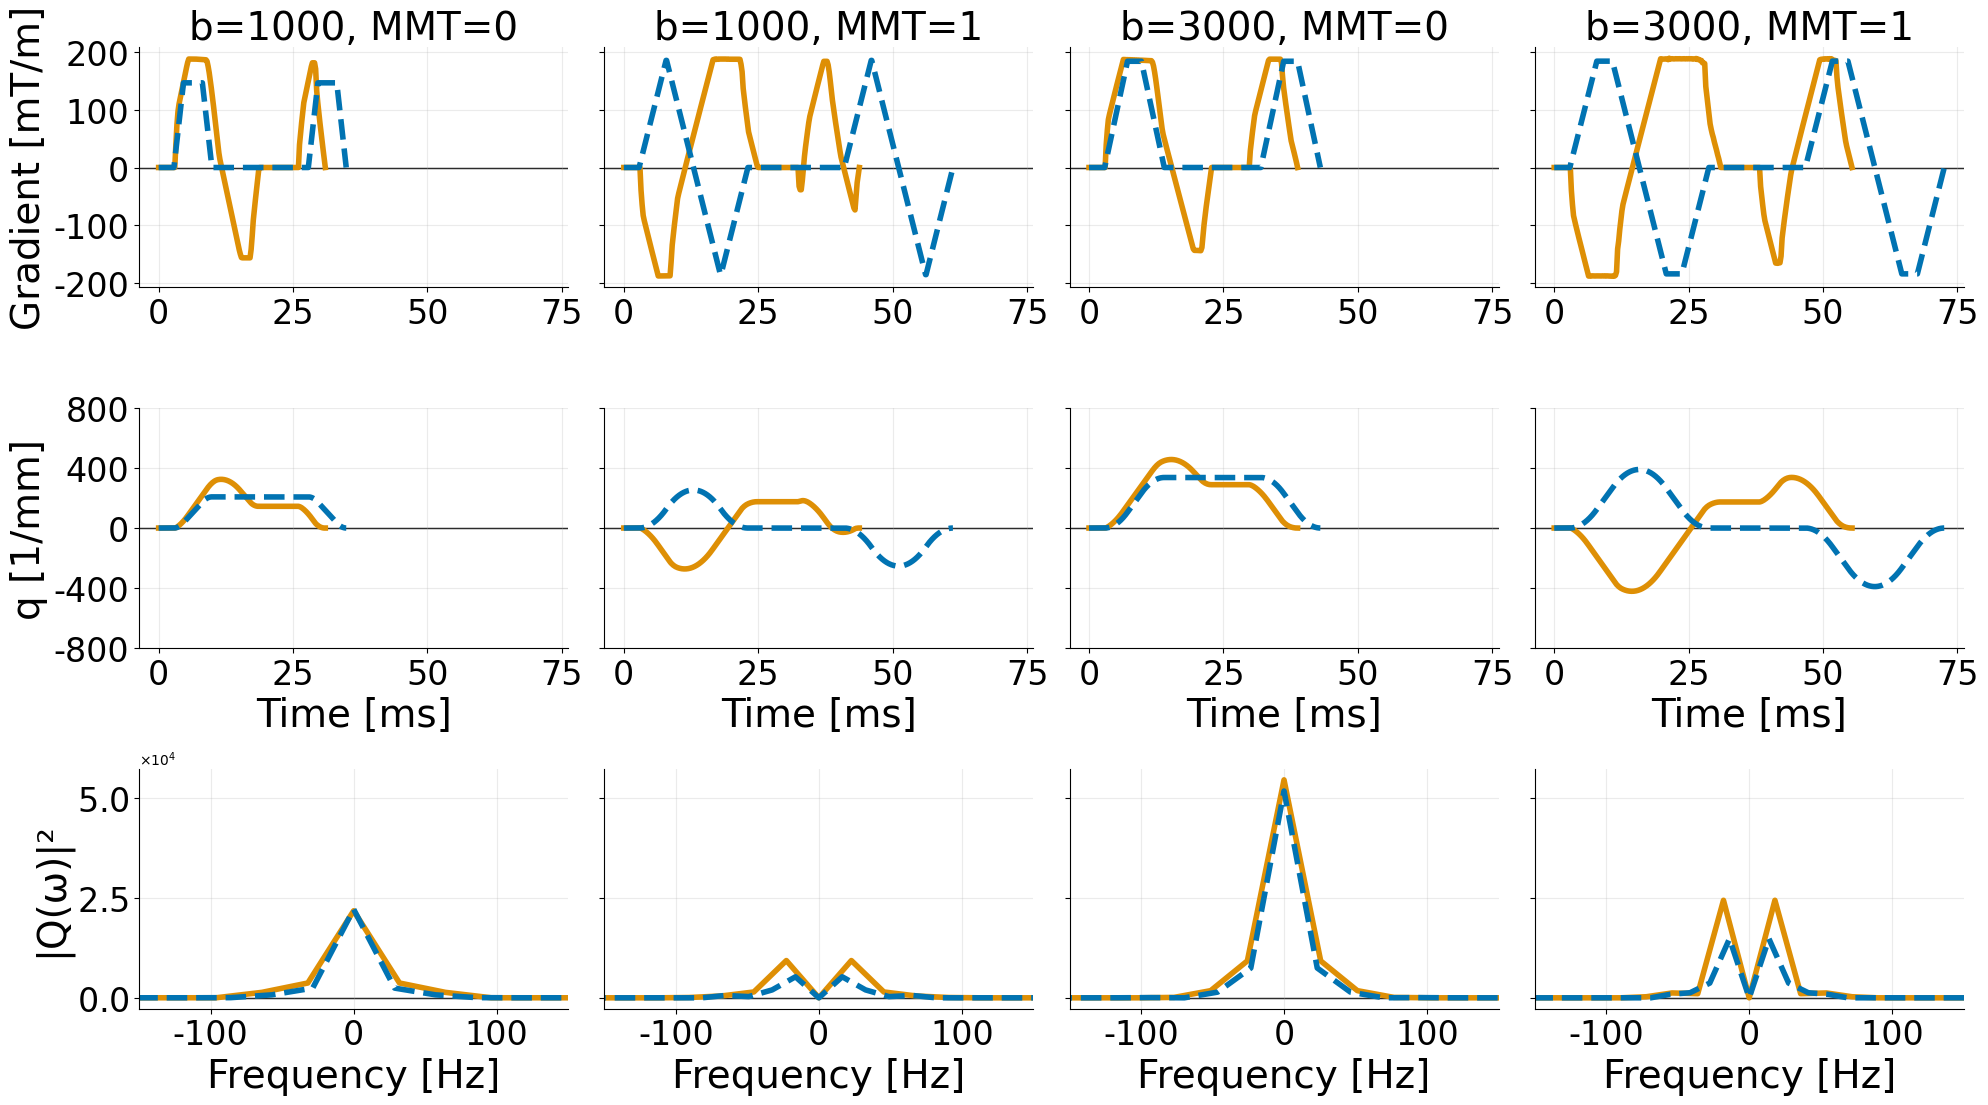

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# Settings
# -------------------------------
bvals = [1000, 3000]
mmts  = [0, 1]
gm = 0.19

COLOR_GROPT = sns.color_palette("colorblind")[1] 
COLOR_TRAP = sns.color_palette("colorblind")[0] # blue # orange

FIG_WIDTH  = 20
FIG_HEIGHT = 12
FONTSIZE_LABEL = 28
FONTSIZE_TICK  = 24
FONTSIZE_LEG   = 24
LW_MAIN = 4
GRID_ALPHA = 0.25

# -------------------------------
# Create figure: 3 rows × 4 columns
# -------------------------------
fig, axs = plt.subplots(3, 4, figsize=(FIG_WIDTH, FIG_HEIGHT), sharex='row', sharey='row')
fig.patch.set_facecolor("white")



# -------------------------------
# Loop over columns (bval × mmt)
# -------------------------------
col_idx = 0
for bval in bvals:
    for mmt in mmts:
        ax_grad = axs[0, col_idx]
        ax_q    = axs[1, col_idx]
        ax_pow  = axs[2, col_idx]

        # Load data
        data = data_dict[(bval, mmt)]
        g_gropt = data['g_gropt']
        g_trap  = data['g_trap']
        dt_gropt = data['dt_gropt']
        dt_trap  = data['dt_trap']
        TE_trap = data['TE_trap']
        TE_gropt = data['TE_gropt']

        g_gropt_in = g_gropt.copy()
        g_trap_in  = g_trap.copy()  
        # Compute q-vectors
        q_gropt = compute_q(g_gropt_in, dt_gropt, TE=TE_gropt)
        q_trap  = compute_q(g_trap_in, dt_trap, TE=TE_trap)

        print('Difference',(TE_gropt - TE_trap)*1e3)

        time_gropt = np.arange(len(q_gropt)) * dt_gropt
        time_trap  = np.arange(len(q_trap)) * dt_trap

        # Compute power spectra
        f_gropt, _, energy_gropt = q_to_energy(q_gropt, dt_gropt)
        f_trap,  _, energy_trap  = q_to_energy(q_trap, dt_trap)

        # -------------------------------
        # Row 1: Gradients
        # -------------------------------
        ax_grad.plot(time_gropt*1e3, g_gropt*1e3, color=COLOR_GROPT, lw=LW_MAIN, label="GrOpt")
        ax_grad.plot(time_trap*1e3, g_trap*1e3, color=COLOR_TRAP, lw=LW_MAIN, label="Trap",alpha = 1,linestyle ='--',)
        #ax_grad.set_xlabel("Time [ms]", fontsize=FONTSIZE_LABEL)
        if col_idx == 0:
            ax_grad.set_ylabel("Gradient [mT/m]", fontsize=FONTSIZE_LABEL)
        ax_grad.grid(True, alpha=GRID_ALPHA)
        ax_grad.spines["top"].set_visible(False)
        ax_grad.spines["right"].set_visible(False)
        ax_grad.set_title(f"b={bval}, MMT={mmt}", fontsize=FONTSIZE_LABEL)
        

        # -------------------------------
        # Row 2: q-vectors
        # -------------------------------
        ax_q.plot(time_gropt*1e3, q_gropt, color=COLOR_GROPT, lw=LW_MAIN, label="GrOpt")
        ax_q.plot(time_trap*1e3, q_trap, color=COLOR_TRAP, lw=LW_MAIN, label="Trap",alpha =1,linestyle ='--',)
        ax_q.set_xlabel("Time [ms]", fontsize=FONTSIZE_LABEL)
        if col_idx == 0:
            ax_q.set_ylabel("q [1/mm]", fontsize=FONTSIZE_LABEL)
        ax_q.grid(True, alpha=GRID_ALPHA)
        ax_q.spines["top"].set_visible(False)
        ax_q.spines["right"].set_visible(False)

        # -------------------------------
        # Row 3: Power spectrum
        # -------------------------------
        ax_pow.plot(f_gropt, energy_gropt, color=COLOR_GROPT, lw=LW_MAIN, label="GrOpt")
        ax_pow.plot(f_trap, energy_trap, color=COLOR_TRAP, lw=LW_MAIN, label="Trap",alpha = 1, linestyle ='--',)
        ax_pow.set_xlabel("Frequency [Hz]", fontsize=FONTSIZE_LABEL)
        if col_idx == 0:
            ax_pow.set_ylabel("|Q(ω)|²", fontsize=FONTSIZE_LABEL)
        ax_pow.grid(True, alpha=GRID_ALPHA)
        ax_pow.spines["top"].set_visible(False)
        ax_pow.spines["right"].set_visible(False)
        ax_pow.set_xlim(-500, 500)

        col_idx += 1

# -------------------------------
# Make all tick labels bigger
# -------------------------------
for ax_row in axs:
    for ax in ax_row:
        # X-axis
        for label in ax.get_xticklabels():
            label.set_fontsize(FONTSIZE_TICK)
        # Y-axis
        for label in ax.get_yticklabels():
            label.set_fontsize(FONTSIZE_TICK)

# Example for gradient axis
ax_grad.set_yticks([-200, -100, 0, 100, 200])  # set specific y-ticks
ax_grad.set_yticklabels([-200, -100, 0, 100, 200], fontsize=FONTSIZE_TICK)

# Example for time axis (x-axis)
ax_grad.set_xticks([0, 25,   50, 75])  # in ms, for instance
ax_grad.set_xticklabels([0, 25, 50, 75], fontsize=FONTSIZE_TICK)
# -------------------------------

ax_q.set_xticks([0, 25,   50, 75])  # in ms, for instance
ax_q.set_xticklabels([0, 25, 50, 75], fontsize=FONTSIZE_TICK)

ax_q.set_yticks([-800, -400, 0, 400, 800])  # set specific y-ticks
ax_q.set_yticklabels([-800, -400, 0, 400,800], fontsize=FONTSIZE_TICK)

#ax_pow.set_yscale('log') # could make log scale
ax_pow.set_xticks([-200, -100, 0, 100, 200])  # in Hz
ax_pow.set_xticklabels([-200, -100, 0, 100, 200], fontsize=FONTSIZE_TICK)
ax_pow.set_xlim([-150,150])

from matplotlib.ticker import ScalarFormatter

# Set y-ticks
ax_pow.set_yticks([0, 25000, 50000])

# Use scientific notation
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))  # forces scientific notation
ax_pow.yaxis.set_major_formatter(formatter)
#ax_pow.tick_params(axis='both', labelsize=FONTSIZE_TICK)  # increase both x and y tick font size

# Optional: increase tick label size
for label in ax_pow.get_yticklabels():
    label.set_fontsize(FONTSIZE_TICK)

# Add horizontal line at y=0 for each axis
for ax_row in axs:
    for ax in ax_row:
        ax.axhline(0, color='black', lw=1, ls='-',zorder= -5)


plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

fig.savefig("gradient_q_power_spectra_comparison.svg", dpi=300)

In [6]:
import pandas as pd
import numpy as np

# -------------------------------
# T2 values
# -------------------------------
T2_WM = 56e-3  # s
T2_GM = 71e-3  # s

# -------------------------------
# Store SNRs
# -------------------------------
snr_dict = {}
summary_list = []

# GrOpt vs Trap differences
for mmt in mmts:  # 0 = M0, 1 = M1
    snr_dict[mmt] = {}
    label = "M0" if mmt == 0 else "M1"

    for bval in bvals:
        data = data_dict[(bval, mmt)]
        TE_trap  = data['TE_trap']
        TE_gropt = data['TE_gropt']

        # Absolute SNR
        SNR_WM_trap  = np.exp(-TE_trap  / T2_WM)
        SNR_WM_gropt = np.exp(-TE_gropt / T2_WM)
        SNR_GM_trap  = np.exp(-TE_trap  / T2_GM)
        SNR_GM_gropt = np.exp(-TE_gropt / T2_GM)

        # Store for later
        snr_dict[mmt][bval] = {
            "WM_trap": SNR_WM_trap,
            "WM_gropt": SNR_WM_gropt,
            "GM_trap": SNR_GM_trap,
            "GM_gropt": SNR_GM_gropt
        }

        # Relative SNR difference GrOpt vs Trap (%)
        diff_WM = (SNR_WM_gropt / SNR_WM_trap - 1) * 100
        diff_GM = (SNR_GM_gropt / SNR_GM_trap - 1) * 100

        summary_list.append({
            "bval": bval,
            "Comparison": label,
            "% Difference WM": diff_WM,
            "% Difference GM": diff_GM,
        })


# Create DataFrame 
df_summary = pd.DataFrame(summary_list)

# Print nicely with 1 decimal
print("\n=== Summary of Theoretical SNR Differences ===")
print(df_summary.round(1))


=== Summary of Theoretical SNR Differences ===
   bval Comparison  % Difference WM  % Difference GM
0  1000         M0              7.2              5.7
1  3000         M0              7.9              6.2
2  1000         M1             36.4             27.7
3  3000         M1             35.8             27.3


In [7]:
import pandas as pd
import numpy as np

# -------------------------------
# T2 values (s)
# -------------------------------
T2_WM  = 56e-3
T2_GM  = 71e-3
T2_CSF = 1500e-3   # ~2 s (adjust if you prefer a different value)

summary_list = []

for mmt in mmts:  # 0 = M0, 1 = M1
    label = "M0" if mmt == 0 else "M1"

    for bval in bvals:
        data = data_dict[(bval, mmt)]
        TE_trap  = data['TE_trap']
        TE_gropt = data['TE_gropt']

        # Absolute SNR
        SNR_WM_trap  = np.exp(-TE_trap  / T2_WM)
        SNR_WM_gropt = np.exp(-TE_gropt / T2_WM)

        SNR_GM_trap  = np.exp(-TE_trap  / T2_GM)
        SNR_GM_gropt = np.exp(-TE_gropt / T2_GM)

        SNR_CSF_trap  = np.exp(-TE_trap  / T2_CSF)
        SNR_CSF_gropt = np.exp(-TE_gropt / T2_CSF)

        # Relative SNR difference (%)
        diff_WM  = (SNR_WM_gropt  / SNR_WM_trap  - 1) * 100
        diff_GM  = (SNR_GM_gropt  / SNR_GM_trap  - 1) * 100
        diff_CSF = (SNR_CSF_gropt / SNR_CSF_trap - 1) * 100

        summary_list.append({
            "b-value": bval,
            "Encoding": label,
            "WM ΔSNR (%)": diff_WM,
            "GM ΔSNR (%)": diff_GM,
            "CSF ΔSNR (%)": diff_CSF,
        })

df_summary = pd.DataFrame(summary_list)

print("\n=== Summary of Theoretical SNR Gain (GrOpt vs Trap) ===")
print(df_summary.round(1))


=== Summary of Theoretical SNR Gain (GrOpt vs Trap) ===
   b-value Encoding  WM ΔSNR (%)  GM ΔSNR (%)  CSF ΔSNR (%)
0     1000       M0          7.2          5.7           0.3
1     3000       M0          7.9          6.2           0.3
2     1000       M1         36.4         27.7           1.2
3     3000       M1         35.8         27.3           1.1


In [8]:
import pandas as pd
import numpy as np

# -------------------------------
# T2 values (s)
# -------------------------------
T2_WM  = 56e-3
T2_GM  = 71e-3
T2_CSF = 1500e-3   # ~1.5–2 s

# -------------------------------
# Tissue weights (%)
# -------------------------------
WM_pct  = 45.0
GM_pct  = 45.0
CSF_pct = 10.0

# Normalize to fractions
w_WM  = WM_pct  / 100.0
w_GM  = GM_pct  / 100.0
w_CSF = CSF_pct / 100.0

summary_list = []

for mmt in mmts:  # 0 = M0, 1 = M1
    label = "M0" if mmt == 0 else "M1"

    for bval in bvals:
        data = data_dict[(bval, mmt)]
        TE_trap  = data['TE_trap']
        TE_gropt = data['TE_gropt']

        # Absolute SNR
        SNR_WM_trap  = np.exp(-TE_trap  / T2_WM)
        SNR_WM_gropt = np.exp(-TE_gropt / T2_WM)

        SNR_GM_trap  = np.exp(-TE_trap  / T2_GM)
        SNR_GM_gropt = np.exp(-TE_gropt / T2_GM)

        SNR_CSF_trap  = np.exp(-TE_trap  / T2_CSF)
        SNR_CSF_gropt = np.exp(-TE_gropt / T2_CSF)

        # Relative SNR difference (%)
        diff_WM  = (SNR_WM_gropt  / SNR_WM_trap  - 1) * 100
        diff_GM  = (SNR_GM_gropt  / SNR_GM_trap  - 1) * 100
        diff_CSF = (SNR_CSF_gropt / SNR_CSF_trap - 1) * 100

        # -------------------------------
        # Weighted SNR gain (%)
        # -------------------------------
        diff_weighted = (
            w_WM  * diff_WM +
            w_GM  * diff_GM +
            w_CSF * diff_CSF
        )

        summary_list.append({
            "b-value": bval,
            "Encoding": label,
            "WM ΔSNR (%)": diff_WM,
            "GM ΔSNR (%)": diff_GM,
            "CSF ΔSNR (%)": diff_CSF,
            "Weighted ΔSNR (%)": diff_weighted
        })

df_summary = pd.DataFrame(summary_list)

print("\n=== Summary of Theoretical SNR Gain (GrOpt vs Trap) ===")
print(df_summary.round(1))


=== Summary of Theoretical SNR Gain (GrOpt vs Trap) ===
   b-value Encoding  WM ΔSNR (%)  GM ΔSNR (%)  CSF ΔSNR (%)  Weighted ΔSNR (%)
0     1000       M0          7.2          5.7           0.3                5.8
1     3000       M0          7.9          6.2           0.3                6.3
2     1000       M1         36.4         27.7           1.2               29.0
3     3000       M1         35.8         27.3           1.1               28.5


In [9]:
num_1 = 19.033
num_2 = 22.872
# percemt difference 
n = (num_2 / num_1 - 1) * 100
print(f"The percent difference is: {n:.3f}%")

The percent difference is: 20.170%


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Eddy-current kernels
# ============================================================

def get2_eddy_mode0(G, lam, dt):
    """Mode-0 eddy-current response"""
    E0 = np.zeros_like(G)
    for i in range(G.size):
        ii = float(G.size - i - 1)
        if i == 0:
            val = -np.exp(-ii * dt / lam)
        else:
            val = np.exp(-(ii + 1.0) * dt / lam) - np.exp(-ii * dt / lam)
        E0[i] = -val
    return E0


def get2_eddy_mode1(G, lam, dt):
    """Mode-1 eddy-current response"""
    E1 = np.zeros_like(G)

    val = 0.0
    for i in range(G.size):
        ii = float(G.size - i - 1)
        val += -np.exp(-ii * dt / lam)
    E1[0] = val * 1e3 * dt

    for i in range(1, G.size):
        ii = float(G.size - i)
        val = -np.exp(-ii * dt / lam)
        E1[i] = val * 1e3 * dt

    return E1


def get_eddy_curves(G, dt, max_lam_ms=100, n_lam=200):
    """
    Sweep eddy-current response across decay constants
    """
    lams_ms = np.linspace(0.1, max_lam_ms, n_lam)
    e0 = []
    e1 = []

    for lam_ms in lams_ms:
        lam = lam_ms * 1e-3  # ms → s
        e0.append(np.sum(get2_eddy_mode0(G, lam, dt) * G))
        e1.append(np.sum(get2_eddy_mode1(G, lam, dt) * G))

    return lams_ms, np.array(e0), np.array(e1)


def eddy_response_exponential(G, dt, lam):
    """
    Alternative exponential eddy-current response
    """
    r = np.diff(np.exp(-np.arange(G.size + 1) * dt / lam))[::-1]
    return 100 * (r @ G)



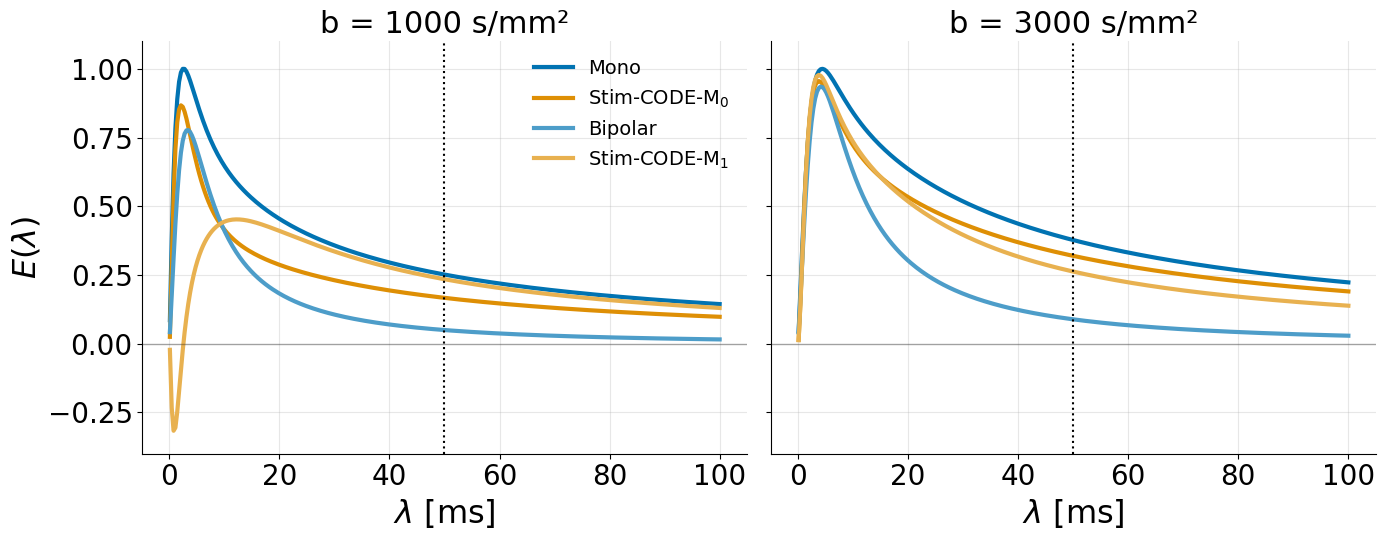

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# USER-DEFINED SETTINGS
# ============================================================

eddy_range = [0.1, 100, 300]  # [lam_min, lam_max, n_points]
eddy_lines = [50]  # ms, vertical lines to highlight




# ============================================================
# LOAD FOUR WAVEFORMS
# ============================================================

bvals = [1000, 3000]
mmts  = [0, 1]

waveforms = {}

for bval in bvals:
    for mmt in mmts:
        data = data_dict[(bval, mmt)]

        waveforms[(bval, mmt, 'trap')] = (
            np.asarray(data['g_trap']).ravel(),
            data['dt_trap']
        )

        waveforms[(bval, mmt, 'gropt')] = (
            np.asarray(data['g_gropt']).ravel(),
            data['dt_gropt']
        )

# ------------------------------------------------------------
# Assign sequences explicitly 
# ------------------------------------------------------------



G_mono,   dt_mono   = waveforms[(bvals[0], 0, 'trap')]
G_bipo,   dt_bipo   = waveforms[(bvals[0], 1, 'trap')]
G_gropt0, dt_gropt0 = waveforms[(bvals[0], 0, 'gropt')]
G_gropt1, dt_gropt1 = waveforms[(bvals[0], 1, 'gropt')]




# ============================================================
# FUNCTION: compute exponential eddy response
# ============================================================

def compute_eddy_exp(G, dt, eddy_range):
    all_lam = np.linspace(eddy_range[0], eddy_range[1], eddy_range[2])
    all_e = []

    for lam_ms in all_lam:
        lam = lam_ms * 1e-3  # ms → s
        r = np.diff(np.exp(-np.arange(G.size + 1) * dt / lam))[::-1]
        e_val = 100 * (r @ G)
        all_e.append(e_val)

    return all_lam, np.array(all_e)

# ============================================================
# COMPUTE EDDY SPECTRA
# ============================================================

lams_mono,   e_mono   = compute_eddy_exp(G_mono,   dt_mono, eddy_range)
_,           e_bipo   = compute_eddy_exp(G_bipo,   dt_bipo, eddy_range)
_,           e_gropt0 = compute_eddy_exp(G_gropt0, dt_gropt0, eddy_range)
_,           e_gropt1 = compute_eddy_exp(G_gropt1, dt_gropt1, eddy_range)

# ============================================================
# NORMALIZE BY MONO PEAK
# ============================================================

norm = np.max(np.abs(e_mono))
e_mono   /= norm
e_bipo   /= norm
e_gropt0 /= norm
e_gropt1 /= norm

# ============================================================
# PLOT ALL WAVEFORMS
# ============================================================



COLOR_GROPT = sns.color_palette("colorblind")[1] 
COLOR_TRAP = sns.color_palette("colorblind")[0] # blue # orange

# Function to lighten a color
def lighten_color(color, amount=0.5):
    """
    Lighten a color by mixing it with white.
    amount: 0 = original color, 1 = white
    """
    import numpy as np
    color = np.array(color)
    white = np.array([1, 1, 1])
    return tuple(color + (white - color) * amount)

# Lighter versions
COLOR_GROPT_LIGHT = lighten_color(COLOR_GROPT, amount=0.3)
COLOR_TRAP_LIGHT  = lighten_color(COLOR_TRAP,  amount=0.3)

import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, bval in zip(axes, bvals):

    # ------------------------------------
    # Extract waveforms for this b-value
    # ------------------------------------
    G_mono,   dt_mono   = waveforms[(bval, 0, 'trap')]
    G_bipo,   dt_bipo   = waveforms[(bval, 1, 'trap')]
    G_gropt0, dt_gropt0 = waveforms[(bval, 0, 'gropt')]
    G_gropt1, dt_gropt1 = waveforms[(bval, 1, 'gropt')]

    if bval == 1000:
        G_mono = G_mono * -1
        G_gropt0 = G_gropt0 * -1
        G_gropt1 = G_gropt1 * -1

    elif bval == 3000:
        G_mono = G_mono * -1
        G_gropt0 = G_gropt0 * -1
        G_gropt1 = G_gropt1 * -1

    # ------------------------------------
    # Compute eddy spectra
    # ------------------------------------
    lams, e_mono   = compute_eddy_exp(G_mono,   dt_mono,   eddy_range)
    _,    e_bipo   = compute_eddy_exp(G_bipo,   dt_bipo,   eddy_range)
    _,    e_gropt0 = compute_eddy_exp(G_gropt0, dt_gropt0, eddy_range)
    _,    e_gropt1 = compute_eddy_exp(G_gropt1, dt_gropt1, eddy_range)

    # ------------------------------------
    # Normalize by mono peak (per b-value)
    # ------------------------------------
    norm = np.max(np.abs(e_mono))
    e_mono   /= norm
    e_bipo   /= norm
    e_gropt0 /= norm
    e_gropt1 /= norm

    # ------------------------------------
    # Plot
    # ------------------------------------
    ax.plot(lams, e_mono,   lw=3, label="Mono",              color=COLOR_TRAP)
    ax.plot(lams, e_gropt0, lw=3, label="Stim-CODE-M$_0$",   color=COLOR_GROPT)
    ax.plot(lams, e_bipo,   lw=3, label="Bipolar",           color=COLOR_TRAP_LIGHT)
    ax.plot(lams, e_gropt1, lw=3, label="Stim-CODE-M$_1$",   color=COLOR_GROPT_LIGHT)

    for e in eddy_lines:
        ax.axvline(e, linestyle=':', color='black')

    ax.axhline(0, color='k', lw=1, alpha=0.3)
    ax.set_ylim([-0.4, 1.1])
    ax.set_title(f"b = {bval} s/mm²", fontsize=22)

    ax.set_xlabel(r"$\lambda$ [ms]", fontsize=23)
    ax.tick_params(axis='both', labelsize=20)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3)

# ------------------------------------
# Shared y-label + legend
# ------------------------------------
axes[0].set_ylabel(r"$E(\lambda)$", fontsize=23)
axes[0].legend(fontsize=14, frameon=False)

plt.tight_layout()
plt.show()

fig.savefig("eddy_spectra_b1000_b3000.svg")

In [18]:
# ================================
# Report max absolute gradient and slew rate
# ================================
results = []

for bval in bvals:
    for mmt in mmts:
        # Load data
        data = data_dict[(bval, mmt)]
        g_gropt = data['g_gropt']
        g_trap  = data['g_trap']
        dt_gropt = data['dt_gropt']
        dt_trap  = data['dt_trap']

        # Max absolute gradient
        max_g_gropt = np.max(np.abs(g_gropt))
        max_g_trap  = np.max(np.abs(g_trap))

        # Compute slew rate (derivative of gradient / dt)
        slew_g_gropt = np.max(np.abs(np.diff(g_gropt) / dt_gropt))
        slew_g_trap  = np.max(np.abs(np.diff(g_trap)  / dt_trap))

        # round gmax smax to 
        results.append({
            "bval": bval,
            "mmt": mmt,
            "MaxG_GrOpt": round(max_g_gropt*1e3),
            "MaxG_Trap": round(max_g_trap*1e3),
            "MaxSlew_GrOpt": round(slew_g_gropt),
            "MaxSlew_Trap": round(slew_g_trap)
        })

# Display results in a table
import pandas as pd
df_results = pd.DataFrame(results)
print(df_results)

   bval  mmt  MaxG_GrOpt  MaxG_Trap  MaxSlew_GrOpt  MaxSlew_Trap
0  1000    0         188        147            198            83
1  1000    1         188        186            198            37
2  3000    0         188        184            198            44
3  3000    1         190        184            200            37


In [21]:
import os
import pydicom
import numpy as np

# -------------------------------
# Main path
# -------------------------------
main_path = "/Volumes/T7/Stim-CODE/Dicoms"

# -------------------------------
# Initialize
# -------------------------------
ages = []
sexes = []

# -------------------------------
# Loop over volunteer folders
# -------------------------------
for vol in os.listdir(main_path):
    vol_path = os.path.join(main_path, vol)
    
    # Only consider folders containing 'Stim_CODE_V'
    if not os.path.isdir(vol_path) or "CODE_V" not in vol:
        continue
    
    # Walk recursively to find first .dcm file
    first_dcm = None
    for root, dirs, files in os.walk(vol_path):
        for f in files:
            if f.endswith(".dcm") and not f.startswith("._"):
                first_dcm = os.path.join(root, f)
                break
        if first_dcm:
            break
    
    if first_dcm:
        try:
            ds = pydicom.dcmread(first_dcm, stop_before_pixels=True)
            # Extract age and sex
            age = ds.PatientAge
            sex = ds.PatientSex
            # Convert age to years if needed (e.g., '025Y' -> 25)
            if age.endswith("Y"):
                age_val = int(age[:-1])
            else:
                age_val = int(age)
            
            ages.append(age_val)
            sexes.append(sex)
            
            print(f"{vol}: Age = {age_val}, Sex = {sex}")
        except Exception as e:
            print(f"Error reading {first_dcm}: {e}")

# -------------------------------
# Compute statistics
# -------------------------------
ages = np.array(ages)
mean_age = np.mean(ages)
std_age  = np.std(ages)

print("\nSummary for Stim_CODE_V volunteers:")
print(f"Number of volunteers: {len(ages)}")
print(f"Mean Age: {mean_age:.1f} ± {std_age:.1f} years")
print(f"Sex distribution: M = {sexes.count('M')}, F = {sexes.count('F')}")

Stim_CODE_V001a_Stim_CODE_V001a_19991209: Age = 26, Sex = M
Stim_CODE_V002_Stim_CODE_V002_20001212: Age = 25, Sex = M
Stim_CODE_V003_Stim_CODE_V003_19951214: Age = 30, Sex = M
Sitm_CODE_V005_Sitm_CODE_V005_19951215: Age = 30, Sex = M
Stim_CODE_V004_Stim_CODE_V004_20011215: Age = 24, Sex = F
Stim_CODE_V006_Stim_CODE_V006_19921216: Age = 33, Sex = F
Stim_CODE_V007_Stim_CODE_V007_19921216: Age = 33, Sex = F
Stim_CODE_V008_Stim_CODE_V008_19811216: Age = 44, Sex = M
Stim_CODE_V009_Stim_CODE_V009_19921216: Age = 33, Sex = M
Stim_CODE_V010_Stim_CODE_V010_19981217: Age = 27, Sex = F

Summary for Stim_CODE_V volunteers:
Number of volunteers: 10
Mean Age: 30.5 ± 5.5 years
Sex distribution: M = 6, F = 4
